In [49]:
import os
import pandas as pd
import textwrap
from llama_index.core import Settings
from llama_index.core.embeddings import MockEmbedding
from llama_index.experimental.query_engine import PandasQueryEngine
from llama_index.llms.groq import Groq

from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = "NA"


In [40]:
meu_llm = Groq(model="llama-3.1-8b-instant",
                    api_key=os.environ.get("GROQ_API_KEY"))

In [41]:
Settings.llm = meu_llm
Settings.embed_model = MockEmbedding(embed_dim=1)

In [42]:
df= pd.read_csv("vendas.csv")

In [43]:
query_engine = PandasQueryEngine(df=df, verbose=True)

In [44]:
response = query_engine.query("Qual é o tipo de produto mais vendido?")

> Pandas Instructions:
```
df['tipo_produto'].value_counts().idxmax()
```
> Pandas Output: Moda


In [45]:
df[df['forma_pagamento'] == 'Dinheiro'].groupby('cidade')['forma_pagamento'].count().idxmax()

'São Caetano'

### Respostas mais elaboradas

In [46]:
query_engine = PandasQueryEngine(df=df, verbose=True, systhesize_response=True)

In [47]:
response = query_engine.query("Qual é a avaliação média de cada filial?")
response

> Pandas Instructions:
```
df.groupby('filial')['avaliacao'].mean()
```
> Pandas Output: filial
A    7.027059
B    6.818072
C    7.072866
Name: avaliacao, dtype: float64


Response(response='filial\nA    7.027059\nB    6.818072\nC    7.072866\nName: avaliacao, dtype: float64', source_nodes=[], metadata={'pandas_instruction_str': "df.groupby('filial')['avaliacao'].mean()", 'raw_pandas_output': 'filial\nA    7.027059\nB    6.818072\nC    7.072866\nName: avaliacao, dtype: float64'})

In [48]:
str(response)

'filial\nA    7.027059\nB    6.818072\nC    7.072866\nName: avaliacao, dtype: float64'

In [50]:
def format_text(response):
    text = response.response
    text_formatted = textwrap.fill(text, width=100)
    print(text_formatted)

In [51]:
format_text(response)

filial A    7.027059 B    6.818072 C    7.072866 Name: avaliacao, dtype: float64


### Geração de Gráficos

In [52]:
response = query_engine.query("Exiba para mim a distribuição das avaliações")

> Pandas Instructions:
```
df['avaliacao'].value_counts()
```
> Pandas Output: avaliacao
6.0     26
6.6     24
        ..
4.6      8
10.0     5
Name: count, Length: 61, dtype: int64


> Pandas Instructions:
```
df['avaliacao'].value_counts().plot(kind='bar')
```


Matplotlib is building the font cache; this may take a moment.


> Pandas Output: Axes(0.125,0.11;0.775x0.77)


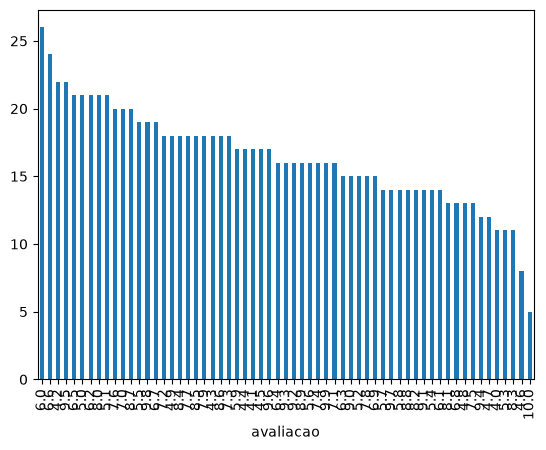

In [54]:
response = query_engine.query("Exiba para mim um gráfico da distribuição das avaliações")

> Pandas Instructions:
```
df.groupby('tipo_produto')['total'].sum().sort_values().plot(kind='barh')
```
> Pandas Output: Axes(0.125,0.11;0.775x0.77)


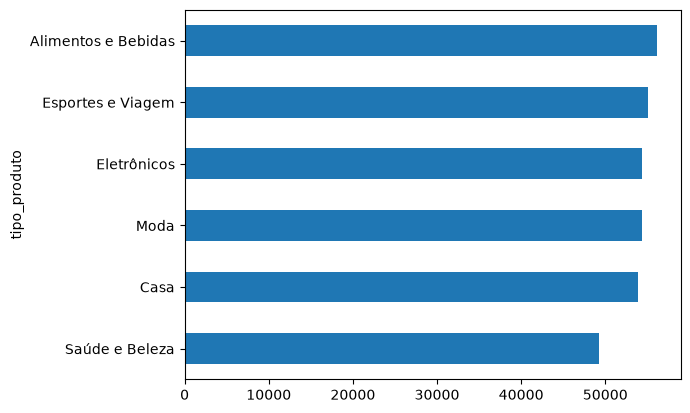

In [55]:
response = query_engine.query("""Crie um gráfico da soma do total por tipo_produto ordenado do menor para o maior e mantenha a barra na horizontal""")
    